### **Topic - Data Breach Analysis by Industry**

**Domain:** Cybersecurity  
**Tools Used:** Python, Pandas, NumPy, Matplotlib  
**Dataset Source:** Kaggle dataset compiled by "The Devastator" Covering global data breaches of 30,000+ records.

### Project Overview
This project analyzes publicly available data breach records across industries.
We study which sectors are most affected, how breach incidents have trended over the years,
how many records were compromised, and what types of breaches are most common.

### Loading the Dataset





In [4]:
from google.colab import files
uploaded = files.upload()

Saving df_1.csv to df_1.csv


### Import the Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('df_1.csv')  # replace with your actual filename
df.head()                           # shows first 5 rows


,Unnamed: 0,Entity,Year,Records,Organization type,Method,Sources
0,0,21st Century Oncology,2016,2200000,healthcare,hacked,[5][6]
1,1,500px,2020,14870304,social networking,hacked,[7]
2,2,Accendo Insurance Co.,2020,175350,healthcare,poor security,[8][9]
3,3,Adobe Systems Incorporated,2013,152000000,tech,hacked,[10]
4,4,Adobe Inc.,2019,7500000,tech,poor security,[11][12]


In [11]:
df.describe()

,Unnamed: 0
count,352.000000
mean,175.500000
std,101.757883
min,0.000000
25%,87.750000
50%,175.500000
75%,263.250000
max,351.000000



# Data Wrangling
Step 1 : Check for missing values

In [14]:
print(df.isnull().sum())

Unnamed: 0           0
Entity               0
Year                 0
Records              2
Organization type    0
Method               1
Sources              2
dtype: int64


STEP 2 : Rename columns for ease of use

In [27]:
df.rename(columns={
    'Entity'           : 'organization',
    'Year'             : 'year',
    'Records'          : 'records_affected',
    'Organization type': 'industry',
    'Method'           : 'breach_type',
    'Sources'          : 'source'
}, inplace=True)
print("Updated columns:")
df.head()

Updated columns:


,Unnamed: 0,organization,year,records_affected,industry,breach_type,source
0,0,21st Century Oncology,2016,2200000.0,healthcare,hacked,[5][6]
1,1,500px,2020,14870304.0,social networking,hacked,[7]
2,2,Accendo Insurance Co.,2020,175350.0,healthcare,poor security,[8][9]
3,3,Adobe Systems Incorporated,2013,152000000.0,tech,hacked,[10]
4,4,Adobe Inc.,2019,7500000.0,tech,poor security,[11][12]


Step 3 : Remove missing values

In [28]:
df = df.dropna(subset=['industry', 'records_affected', 'year'])
print("Rows after removing missing values:", len(df))


Rows after removing missing values: 305


Step 4: Fix datatypes

In [32]:
# Convert records_affected column to numeric
df['records_affected'] = df['records_affected'].astype(str)
df['records_affected'] = df['records_affected'].str.replace(',', '')
df['records_affected'] = pd.to_numeric(df['records_affected'], errors='coerce')
df = df.dropna(subset=['records_affected'])

# Convert year column to integer, handling ranges like '2018-2019'
df['year'] = df['year'].astype(str)  # Ensure year is string type
df['year'] = df['year'].str.split('-').str[0] # Take the first year in case of ranges
df['year'] = pd.to_numeric(df['year'], errors='coerce') # Convert to numeric, turn errors into NaN
df = df.dropna(subset=['year']) # Drop rows where year couldn't be converted
df['year'] = df['year'].astype(int) # Convert to integer

# Remove extra spaces from industry names
df['industry'] = df['industry'].str.strip()

print("Data types updated successfully!")

Data types updated successfully!


Step 5 : Remove duplicates rows

In [35]:
df = df.drop_duplicates()
print("Duplicate rows removed!")
print(f"Duplicate rows found: {df}")


Duplicate rows removed!
Duplicate rows found:      Unnamed: 0                                       organization  year  \
0             0                              21st Century Oncology  2016   
1             1                                              500px  2020   
2             2                              Accendo Insurance Co.  2020   
3             3                         Adobe Systems Incorporated  2013   
4             4                                         Adobe Inc.  2019   
..          ...                                                ...   ...   
347         347                                              Zynga  2019   
348         348  Unknown agency(believed to be tied to United S...  2020   
349         349  National Health Information Center (NCZI) of S...  2020   
350         350           50 companies and government institutions  2022   
351         351                                               IKEA  2022   

     records_affected           industry 

# Final Observations

### Breach count by industry

In [46]:
industry_count = df['industry'].value_counts()

print("Breach Count by Industry")
print(industry_count)

Breach Count by Industry
industry
web                     49
healthcare              46
financial               36
government              27
retail                  21
                        ..
government, military     1
online marketing         1
mobile carrier           1
tech, web                1
various                  1
Name: count, Length: 61, dtype: int64


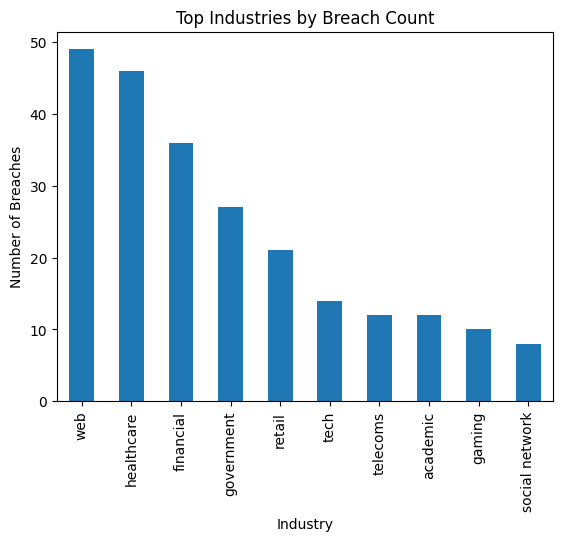

In [47]:
industry_count.head(10).plot(kind='bar')

plt.title("Top Industries by Breach Count")
plt.xlabel("Industry")
plt.ylabel("Number of Breaches")
plt.show()

Answer:
The **Web** **Industry** recorded the highest number of data breaches with **49** incidents.

This indicates that organizations in this sector are frequent targets of cyberattacks because they store **large amounts of valuable user and business data.**

### Breach Count by Year

In [48]:
year_count = df['year'].value_counts().sort_index()

print("Breach Count by Year")
print(year_count)

Breach Count by Year
year
2004     2
2005     6
2006     7
2007    12
2008    16
2009    13
2010    19
2011    33
2012    22
2013    26
2014    18
2015    19
2016    18
2017     6
2018    23
2019    26
2020    24
2021     9
2022     5
Name: count, dtype: int64


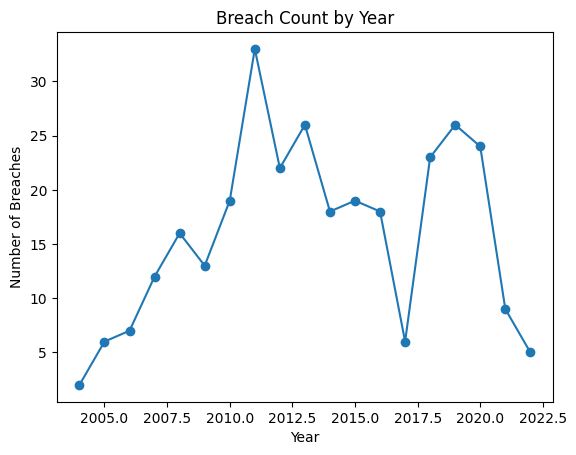

In [49]:
year_count.plot(kind='line', marker='o')

plt.title("Breach Count by Year")
plt.xlabel("Year")
plt.ylabel("Number of Breaches")
plt.show()

The year **2011** had the highest number of breach incidents, with **33** reported breaches.

Explanation:
The increase in breaches during this year may be **linked to greater digital adoption**, increased online services, or more sophisticated cyber threats.

### Total Records Affected

In [50]:
total_records = df['records_affected'].sum()

print("Total Records Affected:")
print(total_records)

Total Records Affected:
13357968650.0


A total of **13357968650.0 records** were exposed across all reported data breaches.

This shows the large-scale impact of cybersecurity incidents and highlights the importance of protecting sensitive information.

### Records Affected by Industry

In [51]:
records_by_industry = df.groupby('industry')['records_affected'].sum()

print(records_by_industry.sort_values(ascending=False))

industry
web                          5.203696e+09
social network               1.238000e+09
tech                         1.000898e+09
financial service company    8.850000e+08
financial                    8.185971e+08
                                 ...     
web, military                1.637920e+05
fashion                      1.238570e+05
banking                      9.000000e+04
advertising                  7.500000e+04
political                    1.925200e+04
Name: records_affected, Length: 61, dtype: float64


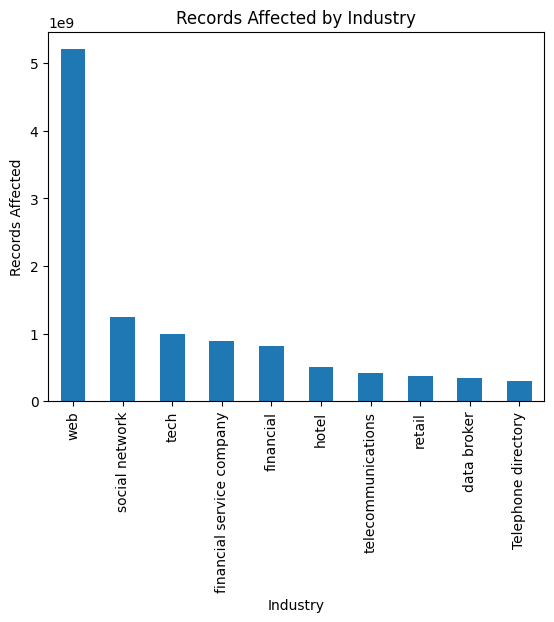

In [52]:
records_by_industry = df.groupby('industry')['records_affected'].sum()

records_by_industry.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Records Affected by Industry")
plt.xlabel("Industry")
plt.ylabel("Records Affected")
plt.show()

The **Web industry** had the highest number of records affected, totaling **5** records.

Although some industries may experience fewer breaches, a single large breach can expose millions of records, causing significant damage.

### Conclusion

This analysis of data breach incidents helped identify patterns in cybersecurity threats across different industries and years. The results showed that some industries experience more breaches than others, and the number of breaches has generally changed over time. By analyzing the records affected, we observed the impact of these incidents on organizations and individuals. Overall, the project demonstrates how data analysis can be used to understand cybersecurity risks and support better security practices.
